# Final Model Comparison

This notebook consolidates the completed RetailRocket purchase conversion experiment. It does not train new models; it loads existing metrics, selects representative models by validation PR-AUC, produces final comparison tables and plots, and summarizes conclusions.

## 1. Project Context

The project predicts whether a high-intent `(visitorid, itemid)` pair will convert in a future 14-day label window using behavioral features from the preceding 30-day observation window. Training uses rolling windows; validation and test are fixed chronological windows.

## 2. Load and Validate Metrics

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs").exists() and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "logistic_metrics": METRICS_DIR / "logistic_baseline_metrics.csv",
    "logistic_thresholds": METRICS_DIR / "logistic_baseline_thresholds.csv",
    "cpu_metrics": METRICS_DIR / "xgboost_cpu_metrics.csv",
    "cpu_thresholds": METRICS_DIR / "xgboost_cpu_thresholds.csv",
    "gpu_metrics": METRICS_DIR / "xgboost_gpu_metrics.csv",
    "gpu_thresholds": METRICS_DIR / "xgboost_gpu_thresholds.csv",
    "cpu_gpu_comparison": METRICS_DIR / "xgboost_cpu_gpu_comparison.csv",
    "dataset_report": METRICS_DIR / "dataset_build_report.csv",
    "feature_report": METRICS_DIR / "feature_build_report.csv",
    "feature_columns": METRICS_DIR / "feature_columns.json",
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    print(f"[OK] Found {name}: {path}")

logistic_metrics = pd.read_csv(paths["logistic_metrics"])
logistic_thresholds = pd.read_csv(paths["logistic_thresholds"])
cpu_metrics = pd.read_csv(paths["cpu_metrics"])
cpu_thresholds = pd.read_csv(paths["cpu_thresholds"])
gpu_metrics = pd.read_csv(paths["gpu_metrics"])
gpu_thresholds = pd.read_csv(paths["gpu_thresholds"])
cpu_gpu_comparison = pd.read_csv(paths["cpu_gpu_comparison"])
dataset_report = pd.read_csv(paths["dataset_report"])
feature_report = pd.read_csv(paths["feature_report"])
with paths["feature_columns"].open("r", encoding="utf-8") as f:
    feature_columns = json.load(f)

print(f"[OK] Loaded {len(feature_columns)} feature columns.")

[OK] Found logistic_metrics: C:\Projects\RetailRocket-XGBoost\outputs\metrics\logistic_baseline_metrics.csv
[OK] Found logistic_thresholds: C:\Projects\RetailRocket-XGBoost\outputs\metrics\logistic_baseline_thresholds.csv
[OK] Found cpu_metrics: C:\Projects\RetailRocket-XGBoost\outputs\metrics\xgboost_cpu_metrics.csv
[OK] Found cpu_thresholds: C:\Projects\RetailRocket-XGBoost\outputs\metrics\xgboost_cpu_thresholds.csv
[OK] Found gpu_metrics: C:\Projects\RetailRocket-XGBoost\outputs\metrics\xgboost_gpu_metrics.csv
[OK] Found gpu_thresholds: C:\Projects\RetailRocket-XGBoost\outputs\metrics\xgboost_gpu_thresholds.csv
[OK] Found cpu_gpu_comparison: C:\Projects\RetailRocket-XGBoost\outputs\metrics\xgboost_cpu_gpu_comparison.csv
[OK] Found dataset_report: C:\Projects\RetailRocket-XGBoost\outputs\metrics\dataset_build_report.csv
[OK] Found feature_report: C:\Projects\RetailRocket-XGBoost\outputs\metrics\feature_build_report.csv
[OK] Found feature_columns: C:\Projects\RetailRocket-XGBoost\outp

## 3. Dataset and Target Summary

The final V1 target uses **Formulation C, High-Intent Hybrid Candidate Pairs**:

- Candidate pair has at least one `addtocart` event in the observation window, or
- Candidate pair has at least two `view` events in the observation window.

A row is positive if the same `(visitorid, itemid)` pair has at least one `transaction` event in the following 14-day label window.

In [2]:
feature_summary = feature_report.copy()
display(feature_summary)

pooled_train = feature_summary.loc[
    (feature_summary["split"].eq("train")) & (feature_summary["snapshot_id"].eq("pooled_train"))
].iloc[0]
val_summary = feature_summary.loc[feature_summary["split"].eq("validation")].iloc[0]
test_summary = feature_summary.loc[feature_summary["split"].eq("test")].iloc[0]

task_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": int(pooled_train["row_count"]),
            "positives": int(pooled_train["positive_count"]),
            "positive_rate": pooled_train["positive_rate"],
        },
        {
            "split": "validation",
            "rows": int(val_summary["row_count"]),
            "positives": int(val_summary["positive_count"]),
            "positive_rate": val_summary["positive_rate"],
        },
        {
            "split": "test",
            "rows": int(test_summary["row_count"]),
            "positives": int(test_summary["positive_count"]),
            "positive_rate": test_summary["positive_rate"],
        },
    ]
)
display(task_summary)

,split,snapshot_id,row_count,positive_count,positive_rate,feature_column_count,obs_start,obs_end_exclusive,label_start,label_end_exclusive
0,train,train_roll_01,77211,87,0.001127,42,2015-05-03,2015-06-02,2015-06-02,2015-06-16
1,train,train_roll_02,78416,73,0.000931,42,2015-05-10,2015-06-09,2015-06-09,2015-06-23
2,train,train_roll_03,77087,73,0.000947,42,2015-05-17,2015-06-16,2015-06-16,2015-06-30
3,train,train_roll_04,76819,78,0.001015,42,2015-05-24,2015-06-23,2015-06-23,2015-07-07
4,train,train_roll_05,76976,64,0.000831,42,2015-05-31,2015-06-30,2015-06-30,2015-07-14
5,train,pooled_train,386509,375,0.000970,42,2015-05-03,2015-06-30,2015-06-02,2015-07-14
6,validation,validation_fixed,79618,71,0.000892,42,2015-06-16,2015-07-16,2015-07-16,2015-07-30
7,test,test_fixed,65546,57,0.000870,42,2015-07-30,2015-08-29,2015-08-29,2015-09-12


,split,rows,positives,positive_rate
0,train,386509,375,0.000970
1,validation,79618,71,0.000892
2,test,65546,57,0.000870


## 4. Final Candidate Formulation

Formulation C was selected as the V1 modeling target because it improved the positive rate over the broad observed-pair baseline while preserving a credible e-commerce interpretation: conversion among items with cart behavior or repeated interest. Rolling Policy 2 training increased usable positive samples, but validation/test positives remain sparse.

## 5. Feature Matrix Summary

In [3]:
display(pd.DataFrame({"feature_column": feature_columns}))
print(f"[OK] Feature column count: {len(feature_columns)}")

,feature_column
0,pair_view_count
1,pair_addtocart_count
2,pair_transaction_count
3,pair_total_events
4,pair_events_last_1d
5,pair_events_last_3d
6,pair_events_last_7d
7,pair_events_last_14d
8,pair_views_last_7d
9,pair_addtocarts_last_7d


[OK] Feature column count: 42


## 6. Model Families Compared

The final comparison includes:

- Logistic Regression baseline
- Best CPU XGBoost model selected by **validation PR-AUC**
- Best GPU XGBoost model selected by **validation PR-AUC**

Test metrics are reported only after model selection. No model is selected by test PR-AUC.

In [4]:
def first_metric_rows(metrics: pd.DataFrame) -> pd.DataFrame:
    return metrics.drop_duplicates(["model_name", "split"]).copy()

logistic_first = first_metric_rows(logistic_metrics)
cpu_first = first_metric_rows(cpu_metrics)
gpu_first = first_metric_rows(gpu_metrics)

best_cpu_model = (
    cpu_first.loc[cpu_first["split"].eq("validation")]
    .sort_values("pr_auc", ascending=False)
    .iloc[0]["model_name"]
)
best_gpu_model = (
    gpu_first.loc[gpu_first["split"].eq("validation")]
    .sort_values("pr_auc", ascending=False)
    .iloc[0]["model_name"]
)

print(f"[OK] Selected CPU model by validation PR-AUC: {best_cpu_model}")
print(f"[OK] Selected GPU model by validation PR-AUC: {best_gpu_model}")

[OK] Selected CPU model by validation PR-AUC: xgboost_cpu_medium_spw_ratio_mds1
[OK] Selected GPU model by validation PR-AUC: xgboost_gpu_medium_spw_ratio_mds1


## 7. Logistic Regression Baseline Results

In [5]:
display(logistic_first)
display(logistic_thresholds)

,model_name,split,threshold_policy,pr_auc,roc_auc,row_count,positive_count,positive_rate,threshold,precision,recall,f1,tp,fp,tn,fn,precision_at_100,recall_at_100,precision_at_500,recall_at_500,precision_at_1000,recall_at_1000
0,logistic_regression_baseline,train,best_f1,0.014772,0.904994,386509,375,0.000970,0.999683,0.041096,0.008000,0.013393,3,70,386064,372,0.05,0.013333,0.040,0.053333,0.033,0.088000
2,logistic_regression_baseline,validation,best_f1,0.017757,0.920234,79618,71,0.000892,0.999683,0.079365,0.070423,0.074627,5,58,79489,66,0.05,0.070423,0.030,0.211268,0.018,0.253521
4,logistic_regression_baseline,test,best_f1,0.013379,0.852662,65546,57,0.000870,0.999683,0.044118,0.105263,0.062176,6,130,65359,51,0.04,0.070175,0.014,0.122807,0.012,0.210526


,model_name,threshold_policy,threshold,pr_auc,roc_auc,row_count,positive_count,positive_rate,precision,recall,f1,tp,fp,tn,fn,validation_best_f1,top_k
0,logistic_regression_baseline,best_f1,0.999683,0.017757,0.920234,79618,71,0.000892,0.079365,0.070423,0.074627,5,58,79489,66,0.074627,NaN
1,logistic_regression_baseline,top_500,0.984529,0.017757,0.920234,79618,71,0.000892,0.030000,0.211268,0.052539,15,485,79062,56,NaN,500.0


## 8. CPU XGBoost Results

In [6]:
cpu_model_summary = cpu_first.pivot_table(
    index="model_name",
    columns="split",
    values=["pr_auc", "roc_auc", "training_time_seconds"],
    aggfunc="first",
)
display(cpu_model_summary)
display(cpu_thresholds)

pr_auc                        roc_auc                      training_time_seconds                      
split                                  test     train validation      test     train validation                  test      train validation
model_name                                                                                                                                 
xgboost_cpu_heavy_spw_ratio_mds1   0.030250  0.999993   0.015576  0.852080  1.000000   0.848906             17.391156  17.391156  17.391156
xgboost_cpu_medium_spw_1           0.051894  0.914614   0.024697  0.875660  0.999549   0.884804              7.482932   7.482932   7.482932
xgboost_cpu_medium_spw_ratio       0.027391  0.999679   0.014509  0.819083  1.000000   0.820012              7.824328   7.824328   7.824328
xgboost_cpu_medium_spw_ratio_mds1  0.026468  0.999104   0.034122  0.811744  0.999999   0.832461              6.820243   6.820243   6.820243
xgboost_cpu_medium_spw_sqrt        0.049252  0.999892   0.019232  0.856557  1.000000   0.870507              7.820534   7.820534   7.820534

,model_name,model_family,threshold_policy,training_time_seconds,objective,tree_method,device,eval_metric,random_state,n_jobs,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,n_estimators,max_depth,learning_rate,scale_pos_weight,pr_auc,roc_auc,row_count,positive_count,positive_rate,threshold,precision,recall,f1,tp,fp,tn,fn,validation_best_f1,top_k,max_delta_step
0,xgboost_cpu_medium_spw_1,medium,best_f1,7.482932,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1.000000,0.024697,0.884804,79618,71,0.000892,0.036958,0.070312,0.126761,0.090452,9,119,79428,62,0.090452,NaN,NaN
1,xgboost_cpu_medium_spw_1,medium,top_500,7.482932,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1.000000,0.024697,0.884804,79618,71,0.000892,0.014180,0.028000,0.197183,0.049037,14,486,79061,57,NaN,500.0,NaN
2,xgboost_cpu_medium_spw_sqrt,medium,best_f1,7.820534,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,32.088793,0.019232,0.870507,79618,71,0.000892,0.071446,0.071429,0.126761,0.091371,9,117,79430,62,0.091371,NaN,NaN
3,xgboost_cpu_medium_spw_sqrt,medium,top_500,7.820534,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,32.088793,0.019232,0.870507,79618,71,0.000892,0.020683,0.030000,0.211268,0.052539,15,485,79062,56,NaN,500.0,NaN
4,xgboost_cpu_medium_spw_ratio,medium,best_f1,7.824328,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.014509,0.820012,79618,71,0.000892,0.399725,0.102564,0.056338,0.072727,4,35,79512,67,0.072727,NaN,NaN
5,xgboost_cpu_medium_spw_ratio,medium,top_500,7.824328,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.014509,0.820012,79618,71,0.000892,0.058444,0.020000,0.140845,0.035026,10,490,79057,61,NaN,500.0,NaN
6,xgboost_cpu_medium_spw_ratio_mds1,medium,best_f1,6.820243,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.034122,0.832461,79618,71,0.000892,0.342992,0.087500,0.098592,0.092715,7,73,79474,64,0.092715,NaN,1.0
7,xgboost_cpu_medium_spw_ratio_mds1,medium,top_500,6.820243,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.034122,0.832461,79618,71,0.000892,0.097040,0.024000,0.169014,0.042032,12,488,79059,59,NaN,500.0,1.0
8,xgboost_cpu_heavy_spw_ratio_mds1,heavy,best_f1,17.391156,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,1200,10,0.03,1029.690667,0.015576,0.848906,79618,71,0.000892,0.071201,0.067961,0.098592,0.080460,7,96,79451,64,0.080460,NaN,1.0
9,xgboost_cpu_heavy_spw_ratio_mds1,heavy,top_500,17.391156,binary:logistic,hist,cpu,aucpr,42,-1,0.8,0.8,5,1.0,0.0,1200,10,0.03,1029.690667,0.015576,0.848906,79618,71,0.000892,0.014161,0.022000,0.154930,0.038529,11,489,79058,60,NaN,500.0,1.0


## 9. GPU XGBoost Results

In [7]:
gpu_model_summary = gpu_first.pivot_table(
    index="model_name",
    columns="split",
    values=["pr_auc", "roc_auc", "training_time_seconds"],
    aggfunc="first",
)
display(gpu_model_summary)
display(gpu_thresholds)

pr_auc                        roc_auc                      training_time_seconds                     
split                                  test     train validation      test     train validation                  test     train validation
model_name                                                                                                                                
xgboost_gpu_heavy_spw_ratio_mds1   0.037550  0.999993   0.017065  0.841333  1.000000   0.847713              8.823119  8.823119   8.823119
xgboost_gpu_medium_spw_1           0.060860  0.917853   0.022244  0.870525  0.999577   0.875735              2.729647  2.729647   2.729647
xgboost_gpu_medium_spw_ratio       0.026862  0.999703   0.013112  0.822825  1.000000   0.833496              3.036774  3.036774   3.036774
xgboost_gpu_medium_spw_ratio_mds1  0.032319  0.998398   0.024310  0.803964  0.999999   0.828576              2.828797  2.828797   2.828797
xgboost_gpu_medium_spw_sqrt        0.038243  0.999847   0.016611  0.862877  1.000000   0.875182              2.822977  2.822977   2.822977

,model_name,model_family,threshold_policy,training_time_seconds,objective,tree_method,device,eval_metric,random_state,n_jobs,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,n_estimators,max_depth,learning_rate,scale_pos_weight,pr_auc,roc_auc,row_count,positive_count,positive_rate,threshold,precision,recall,f1,tp,fp,tn,fn,validation_best_f1,top_k,max_delta_step
0,xgboost_gpu_medium_spw_1,medium,best_f1,2.729647,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1.000000,0.022244,0.875735,79618,71,0.000892,0.071956,0.139535,0.084507,0.105263,6,37,79510,65,0.105263,NaN,NaN
1,xgboost_gpu_medium_spw_1,medium,top_500,2.729647,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1.000000,0.022244,0.875735,79618,71,0.000892,0.014690,0.022000,0.154930,0.038529,11,489,79058,60,NaN,500.0,NaN
2,xgboost_gpu_medium_spw_sqrt,medium,best_f1,2.822977,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,32.088793,0.016611,0.875182,79618,71,0.000892,0.150823,0.119048,0.070423,0.088496,5,37,79510,66,0.088496,NaN,NaN
3,xgboost_gpu_medium_spw_sqrt,medium,top_500,2.822977,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,32.088793,0.016611,0.875182,79618,71,0.000892,0.022084,0.022000,0.154930,0.038529,11,489,79058,60,NaN,500.0,NaN
4,xgboost_gpu_medium_spw_ratio,medium,best_f1,3.036774,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.013112,0.833496,79618,71,0.000892,0.233753,0.058252,0.084507,0.068966,6,97,79450,65,0.068966,NaN,NaN
5,xgboost_gpu_medium_spw_ratio,medium,top_500,3.036774,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.013112,0.833496,79618,71,0.000892,0.056876,0.020000,0.140845,0.035026,10,490,79057,61,NaN,500.0,NaN
6,xgboost_gpu_medium_spw_ratio_mds1,medium,best_f1,2.828797,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.024310,0.828576,79618,71,0.000892,0.379583,0.098765,0.112676,0.105263,8,73,79474,63,0.105263,NaN,1.0
7,xgboost_gpu_medium_spw_ratio_mds1,medium,top_500,2.828797,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,500,8,0.05,1029.690667,0.024310,0.828576,79618,71,0.000892,0.103253,0.024000,0.169014,0.042032,12,488,79059,59,NaN,500.0,1.0
8,xgboost_gpu_heavy_spw_ratio_mds1,heavy,best_f1,8.823119,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,1200,10,0.03,1029.690667,0.017065,0.847713,79618,71,0.000892,0.140259,0.102041,0.070423,0.083333,5,44,79503,66,0.083333,NaN,1.0
9,xgboost_gpu_heavy_spw_ratio_mds1,heavy,top_500,8.823119,binary:logistic,hist,cuda,aucpr,42,-1,0.8,0.8,5,1.0,0.0,1200,10,0.03,1029.690667,0.017065,0.847713,79618,71,0.000892,0.013400,0.026000,0.183099,0.045534,13,487,79060,58,NaN,500.0,1.0


## 10. Final Model Quality Comparison

In [8]:
def selected_model_row(
    label: str,
    selected_model_name: str,
    metrics_first: pd.DataFrame,
    training_time_available: bool = True,
) -> dict:
    val = metrics_first.loc[
        metrics_first["model_name"].eq(selected_model_name) & metrics_first["split"].eq("validation")
    ].iloc[0]
    test = metrics_first.loc[
        metrics_first["model_name"].eq(selected_model_name) & metrics_first["split"].eq("test")
    ].iloc[0]
    return {
        "model_family": label,
        "selected_model_name": selected_model_name,
        "validation_pr_auc": val["pr_auc"],
        "validation_roc_auc": val["roc_auc"],
        "test_pr_auc": test["pr_auc"],
        "test_roc_auc": test["roc_auc"],
        "test_precision_at_100": test["precision_at_100"],
        "test_recall_at_100": test["recall_at_100"],
        "test_precision_at_500": test["precision_at_500"],
        "test_recall_at_500": test["recall_at_500"],
        "test_precision_at_1000": test["precision_at_1000"],
        "test_recall_at_1000": test["recall_at_1000"],
        "training_time_seconds": val["training_time_seconds"] if training_time_available and "training_time_seconds" in val.index else np.nan,
    }

logistic_model_name = logistic_first["model_name"].iloc[0]
final_comparison = pd.DataFrame(
    [
        selected_model_row("Logistic Regression", logistic_model_name, logistic_first, False),
        selected_model_row("CPU XGBoost", best_cpu_model, cpu_first, True),
        selected_model_row("GPU XGBoost", best_gpu_model, gpu_first, True),
    ]
)
final_comparison_path = METRICS_DIR / "final_model_comparison.csv"
final_comparison.to_csv(final_comparison_path, index=False)
print(f"[OK] Saved final model comparison: {final_comparison_path}")
display(final_comparison)

[OK] Saved final model comparison: C:\Projects\RetailRocket-XGBoost\outputs\metrics\final_model_comparison.csv


,model_family,selected_model_name,validation_pr_auc,validation_roc_auc,test_pr_auc,test_roc_auc,test_precision_at_100,test_recall_at_100,test_precision_at_500,test_recall_at_500,test_precision_at_1000,test_recall_at_1000,training_time_seconds
0,Logistic Regression,logistic_regression_baseline,0.017757,0.920234,0.013379,0.852662,0.04,0.070175,0.014,0.122807,0.012,0.210526,NaN
1,CPU XGBoost,xgboost_cpu_medium_spw_ratio_mds1,0.034122,0.832461,0.026468,0.811744,0.05,0.087719,0.014,0.122807,0.010,0.175439,6.820243
2,GPU XGBoost,xgboost_gpu_medium_spw_ratio_mds1,0.024310,0.828576,0.032319,0.803964,0.05,0.087719,0.014,0.122807,0.008,0.140351,2.828797


## 11. Final Improvement Summary

In [9]:
baseline = final_comparison.loc[final_comparison["model_family"].eq("Logistic Regression")].iloc[0]
improvement_rows = []
for _, row in final_comparison.loc[~final_comparison["model_family"].eq("Logistic Regression")].iterrows():
    improvement_rows.append(
        {
            "model_family": row["model_family"],
            "selected_model_name": row["selected_model_name"],
            "validation_pr_auc_multiplier": row["validation_pr_auc"] / baseline["validation_pr_auc"],
            "test_pr_auc_multiplier": row["test_pr_auc"] / baseline["test_pr_auc"],
            "test_precision_at_100_difference": row["test_precision_at_100"] - baseline["test_precision_at_100"],
            "test_recall_at_100_difference": row["test_recall_at_100"] - baseline["test_recall_at_100"],
            "test_precision_at_500_difference": row["test_precision_at_500"] - baseline["test_precision_at_500"],
            "test_recall_at_500_difference": row["test_recall_at_500"] - baseline["test_recall_at_500"],
        }
    )
improvement_summary = pd.DataFrame(improvement_rows)
improvement_path = METRICS_DIR / "final_model_improvement_summary.csv"
improvement_summary.to_csv(improvement_path, index=False)
print(f"[OK] Saved final improvement summary: {improvement_path}")
display(improvement_summary)

[OK] Saved final improvement summary: C:\Projects\RetailRocket-XGBoost\outputs\metrics\final_model_improvement_summary.csv


,model_family,selected_model_name,validation_pr_auc_multiplier,test_pr_auc_multiplier,test_precision_at_100_difference,test_recall_at_100_difference,test_precision_at_500_difference,test_recall_at_500_difference
0,CPU XGBoost,xgboost_cpu_medium_spw_ratio_mds1,1.921612,1.978400,0.01,0.017544,0.0,0.0
1,GPU XGBoost,xgboost_gpu_medium_spw_ratio_mds1,1.369055,2.415728,0.01,0.017544,0.0,0.0


## 12. Final Plots

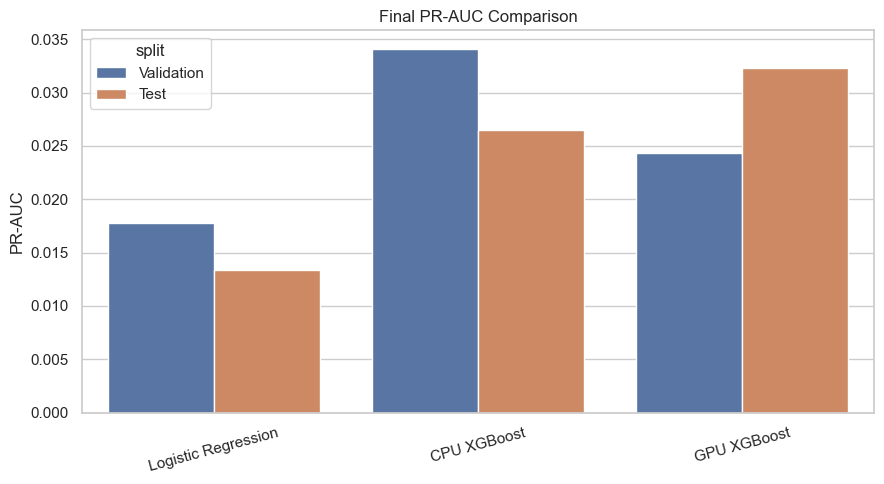

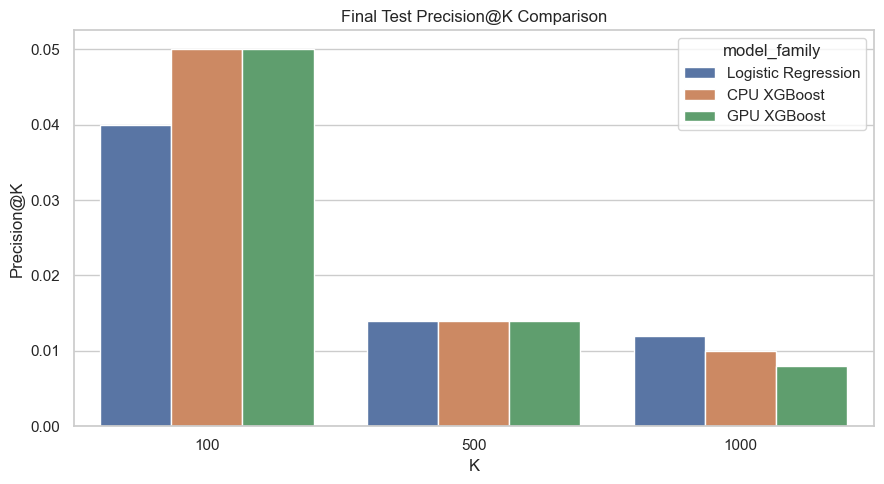

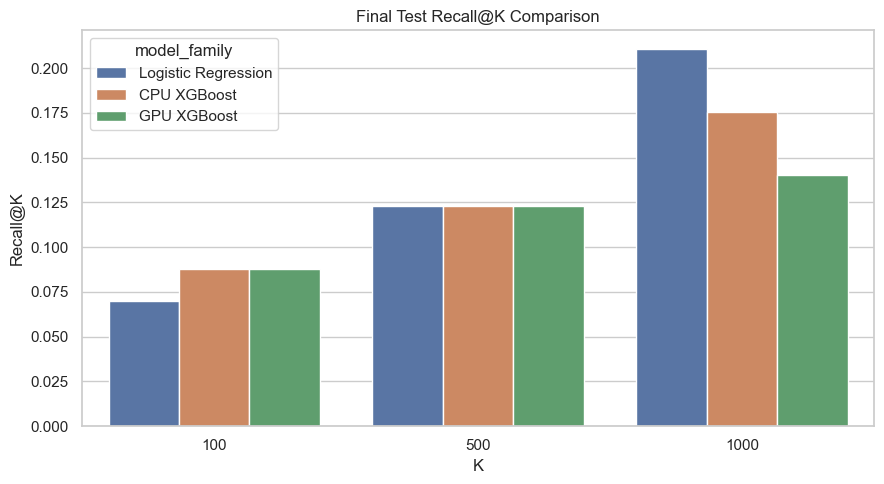

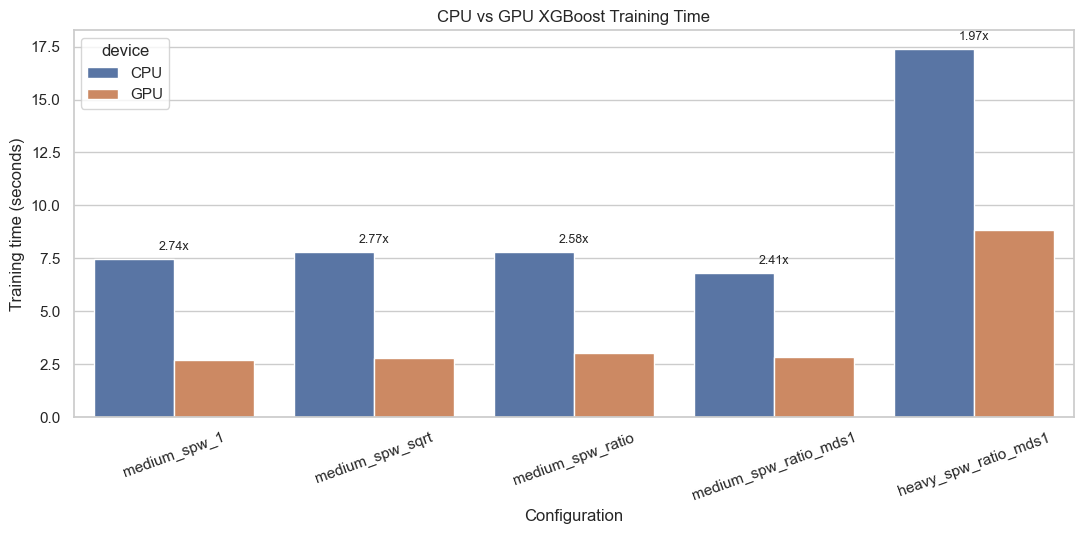

[OK] Saved figures: C:\Projects\RetailRocket-XGBoost\outputs\figures\final_pr_auc_comparison.png, C:\Projects\RetailRocket-XGBoost\outputs\figures\final_precision_at_k_comparison.png, C:\Projects\RetailRocket-XGBoost\outputs\figures\final_recall_at_k_comparison.png, C:\Projects\RetailRocket-XGBoost\outputs\figures\final_cpu_gpu_training_time_comparison.png


In [10]:
pr_plot_df = final_comparison.melt(
    id_vars=["model_family"],
    value_vars=["validation_pr_auc", "test_pr_auc"],
    var_name="split_metric",
    value_name="pr_auc",
)
pr_plot_df["split"] = pr_plot_df["split_metric"].str.replace("_pr_auc", "", regex=False).str.title()
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=pr_plot_df, x="model_family", y="pr_auc", hue="split", ax=ax)
ax.set_title("Final PR-AUC Comparison")
ax.set_xlabel("")
ax.set_ylabel("PR-AUC")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
final_pr_path = FIGURES_DIR / "final_pr_auc_comparison.png"
fig.savefig(final_pr_path, dpi=150)
plt.show()

precision_plot_df = final_comparison.melt(
    id_vars=["model_family"],
    value_vars=["test_precision_at_100", "test_precision_at_500", "test_precision_at_1000"],
    var_name="metric",
    value_name="precision",
)
precision_plot_df["K"] = precision_plot_df["metric"].str.extract(r"(\d+)$")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=precision_plot_df, x="K", y="precision", hue="model_family", ax=ax)
ax.set_title("Final Test Precision@K Comparison")
ax.set_xlabel("K")
ax.set_ylabel("Precision@K")
plt.tight_layout()
final_precision_path = FIGURES_DIR / "final_precision_at_k_comparison.png"
fig.savefig(final_precision_path, dpi=150)
plt.show()

recall_plot_df = final_comparison.melt(
    id_vars=["model_family"],
    value_vars=["test_recall_at_100", "test_recall_at_500", "test_recall_at_1000"],
    var_name="metric",
    value_name="recall",
)
recall_plot_df["K"] = recall_plot_df["metric"].str.extract(r"(\d+)$")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=recall_plot_df, x="K", y="recall", hue="model_family", ax=ax)
ax.set_title("Final Test Recall@K Comparison")
ax.set_xlabel("K")
ax.set_ylabel("Recall@K")
plt.tight_layout()
final_recall_path = FIGURES_DIR / "final_recall_at_k_comparison.png"
fig.savefig(final_recall_path, dpi=150)
plt.show()

time_rows = cpu_gpu_comparison.loc[
    cpu_gpu_comparison["comparison_type"].eq("cpu_gpu_matching_config")
].copy()
time_plot_df = time_rows.melt(
    id_vars=["config", "gpu_cpu_speedup"],
    value_vars=["cpu_training_time_seconds", "gpu_training_time_seconds"],
    var_name="device",
    value_name="training_time_seconds",
)
time_plot_df["device"] = time_plot_df["device"].map(
    {"cpu_training_time_seconds": "CPU", "gpu_training_time_seconds": "GPU"}
)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=time_plot_df, x="config", y="training_time_seconds", hue="device", ax=ax)
ax.set_title("CPU vs GPU XGBoost Training Time")
ax.set_xlabel("Configuration")
ax.set_ylabel("Training time (seconds)")
ax.tick_params(axis="x", rotation=20)
for idx, row in time_rows.reset_index(drop=True).iterrows():
    ax.text(idx, max(row["cpu_training_time_seconds"], row["gpu_training_time_seconds"]) + 0.4, f"{row['gpu_cpu_speedup']:.2f}x", ha="center", fontsize=9)
plt.tight_layout()
final_time_path = FIGURES_DIR / "final_cpu_gpu_training_time_comparison.png"
fig.savefig(final_time_path, dpi=150)
plt.show()

print(f"[OK] Saved figures: {final_pr_path}, {final_precision_path}, {final_recall_path}, {final_time_path}")

## 13. CPU vs GPU Training-Time Benchmark

GPU XGBoost reduced training time across matching configurations. In this experiment the speedup ranged from roughly 2x to 2.8x depending on model size and imbalance setting.

In [11]:
time_summary = cpu_gpu_comparison.loc[
    cpu_gpu_comparison["comparison_type"].eq("cpu_gpu_matching_config"),
    [
        "config",
        "cpu_training_time_seconds",
        "gpu_training_time_seconds",
        "gpu_cpu_speedup",
        "cpu_validation_pr_auc",
        "gpu_validation_pr_auc",
        "cpu_test_pr_auc",
        "gpu_test_pr_auc",
    ],
].copy()
display(time_summary)

,config,cpu_training_time_seconds,gpu_training_time_seconds,gpu_cpu_speedup,cpu_validation_pr_auc,gpu_validation_pr_auc,cpu_test_pr_auc,gpu_test_pr_auc
0,medium_spw_1,7.482932,2.729647,2.741355,0.024697,0.022244,0.051894,0.060860
1,medium_spw_sqrt,7.820534,2.822977,2.770314,0.019232,0.016611,0.049252,0.038243
2,medium_spw_ratio,7.824328,3.036774,2.576526,0.014509,0.013112,0.027391,0.026862
3,medium_spw_ratio_mds1,6.820243,2.828797,2.411005,0.034122,0.024310,0.026468,0.032319
4,heavy_spw_ratio_mds1,17.391156,8.823119,1.971089,0.015576,0.017065,0.030250,0.037550


## 14. Key Findings

1. Logistic Regression established a useful linear baseline, but PR-AUC remained low under extreme sparsity.
2. CPU XGBoost substantially improved validation and test PR-AUC over Logistic Regression.
3. GPU XGBoost accelerated training by about 2x to 2.8x depending on configuration.
4. GPU XGBoost did not clearly beat CPU XGBoost by validation-selected model quality in this run, so the proper conclusion is faster training with broadly comparable ranking behavior, not unconditional quality improvement.
5. Validation and test positives are small, so metric variance remains a major caveat.

## 15. Caveats and Next Steps

- The test set has only 57 positives, so PR-AUC and top-K metrics can move noticeably with small ranking changes.
- ROC-AUC is reported for context, but PR-AUC and Precision@K are more meaningful for this conversion task.
- Current features use only `events.csv`; future versions could add item/category metadata, longer windows, or alternative targets.
- The next project step should be a polished final writeup, plus optional robustness checks across alternative windows or candidate definitions.